# Testing Sphere Inversion Augmentation

This notebook tests the patch-level sphere inversion augmentation functionality.

The augmentation:
- Inverts a sphere near the center of each patch in the mag image
- Alpha blends the inverted sphere with the original patch
- Supports configurable radius range, alpha blending, and center jitter
- Applied with a configurable probability per patch


In [1]:
# Import necessary modules
import sys
from pathlib import Path
import torch
import torchio as tio
import matplotlib.pyplot as plt
import numpy as np
from hydra import compose, initialize_config_dir

# Add project root to path (notebooks are typically run from project root)
# If running from a different directory, adjust the path accordingly
project_root = Path.cwd()
if not (project_root / "src" / "vascular_superenhancement").exists():
    # Try parent directory
    project_root = project_root.parent
if (project_root / "src" / "vascular_superenhancement").exists():
    sys.path.insert(0, str(project_root / "src"))

from vascular_superenhancement.training.transforms import apply_sphere_inversion_to_patch
from vascular_superenhancement.training.datasets import make_subject, build_subjects_dataset
from vascular_superenhancement.training.dataloading import build_train_loader
from vascular_superenhancement.data_management.patients import Patient
from vascular_superenhancement.utils.path_config import load_path_config
from vascular_superenhancement.training.transforms import build_transforms


Found project root at: /mnt/yeluru/vascular-superenhancement-4d-flow


## Load Configuration and Create Test Subject


In [2]:
# Load Hydra config
config_dir = Path("~/vascular-superenhancement-4d-flow/hydra_configs").expanduser().absolute()

with initialize_config_dir(config_dir=str(config_dir), version_base="1.1"):
    cfg = compose(config_name="config", overrides=[
        "train.debug=True",
        "train.patch_size=[96,96,48]",
        "data.spacing=[1.4,1.4,1.4]",
        "train.sphere_inversion_probability=1.0",  # Always apply for testing
    ])

print("Config loaded successfully!")
print(f"Patch size: {cfg.train.patch_size}")
print(f"Sphere inversion probability: {cfg.train.get('sphere_inversion_probability', 0.5)}")
print(cfg.path_config.path_config_name)

Config loaded successfully!
Patch size: [96, 96, 48]
Sphere inversion probability: 1.0
default


In [3]:
# Create subject with transforms
transforms = build_transforms(cfg, train=True)

# Build a test dataset
training_dataset = build_subjects_dataset(
    "train",
    Path(cfg.data.splits_path),
    cfg.path_config.path_config_name,
    transforms=transforms,
    debug=True,
    include_all_timepoints=False
)

training_loader = build_train_loader(training_dataset, cfg, subject_sampler=None, train=True)



2026-01-09 15:43:49,543 - DEBUG - Patient Bukrukesh log file: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/sample_patients/logs/patients/Bukrukesh.log
2026-01-09 15:43:49,548 - DEBUG - Converted 3D Cine series number to integer: 1600
2026-01-09 15:43:49,548 - DEBUG - Successfully initialized Bukrukesh from database
2026-01-09 15:43:50,018 - DEBUG - Added 20 subjects for patient Bukrukesh


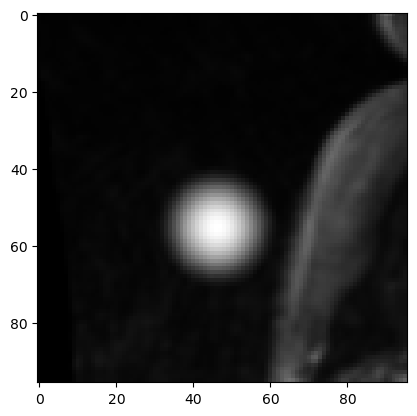

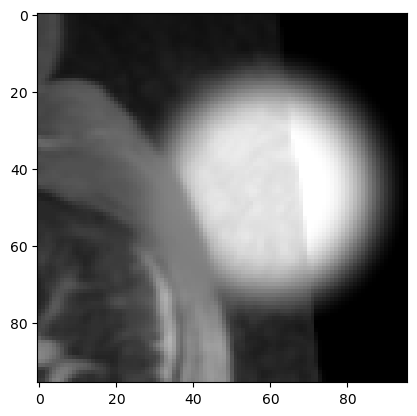

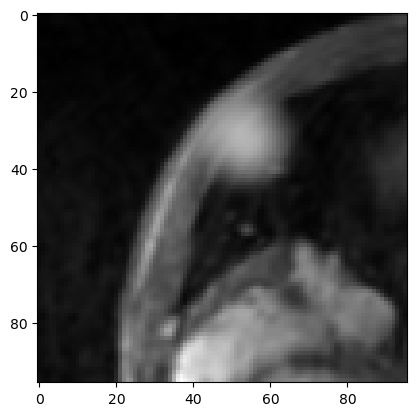

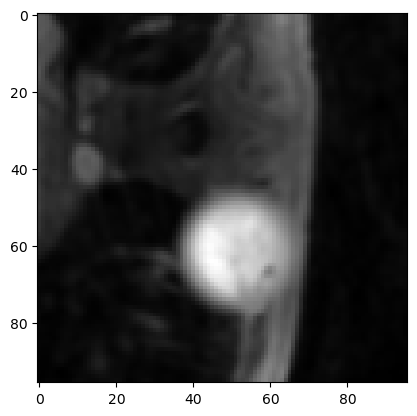

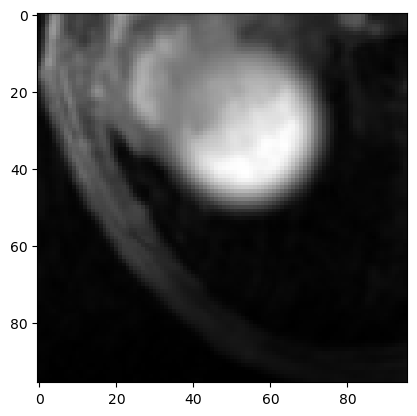

In [4]:
for batch in training_loader:
    first = batch["mag"][tio.DATA][0,:,:,:].cpu().numpy()
    plt.imshow(first[0,:,:,24], cmap="gray")
    plt.show()
    